In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# SMOTE와 Pipeline (Data Leakage 방지용)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [11]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Support Vector Machine

### Cell 1: 데이터 로드 및 Feature Engineering

In [12]:
df.columns = df.columns.str.strip()

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]

#for i in range(6):
#    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

#df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
#input_cols = current_cols + speed_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
input_cols = current_cols + speed_cols
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 24)
피처 개수: 12개


### Cell 2: 타겟 변수 생성

In [13]:
# 통합 이진 타겟(System_Failure) 생성: Protective Stop 또는 Grip Lost 발생 시 1
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())
# 0: Normal(정상), 1: Failure(고장)

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: Train/Test 분할 및 스케일링

In [14]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. 데이터 스케일링 (SVM은 거리 기반 모델이므로 변수 스케일에 매우 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 12)
테스트 데이터 크기: (1471, 12)


### Cell 4: SVM 모델 학습 및 하이퍼파라미터 튜닝

In [15]:
# 1. Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Imblearn Pipeline 구축 (Fold 내에서 SMOTE 적용 -> SVM 학습)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)) # probability=True는 추후 AUC 등 확률 계산을 위함
])

# 3. 튜닝할 파라미터 그리드 (SVM용 설정)
# 주의: SVM은 연산량이 많아 그리드가 크면 오래 걸립니다. 
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto'] # 주로 rbf 커널에 영향을 줌
}

# 4. GridSearchCV 실행 (데이터 불균형을 고려해 scoring을 'f1_macro'로 설정)
print("--- SVM 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 (다소 시간이 소요될 수 있습니다) ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1, # CPU 코어 전체 사용
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

# 5. 최적 파라미터 및 결과 확인
print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('svm__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- SVM 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 (다소 시간이 소요될 수 있습니다) ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

### Cell 5: 상위 10개 모델 성능 종합 (Train/Test Gap 분석)

In [ ]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 SVM 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 파이프라인(SMOTE+SVM) 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('svm', SVC(
            C=params.get('svm__C', 1.0),
            kernel=params.get('svm__kernel', 'rbf'),
            gamma=params.get('svm__gamma', 'scale'),
            probability=True,
            random_state=42
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 평가지표 계산
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환
    c_val = params.get('svm__C', '-')
    ker_val = params.get('svm__kernel', '-')
    gam_val = params.get('svm__gamma', '-')
    param_short = f"C={c_val}, K={ker_val}, G={gam_val}"
    
    # 결과 저장
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)


[Train 데이터 평가]
Accuracy (정확도) : 0.8916
F1-Macro Score    : 0.701776

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.91      0.94      5470
 1 (Failure)       0.36      0.67      0.46       414

    accuracy                           0.89      5884
   macro avg       0.66      0.79      0.70      5884
weighted avg       0.93      0.89      0.91      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.8906
F1-Macro Score    : 0.689192

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.91      0.94      1367
 1 (Failure)       0.34      0.61      0.44       104

    accuracy                           0.89      1471
   macro avg       0.66      0.76      0.69      1471
weighted avg       0.92      0.89      0.90      1471



### Cell 6: 선택한 순위 모델 상세 분석 리포트

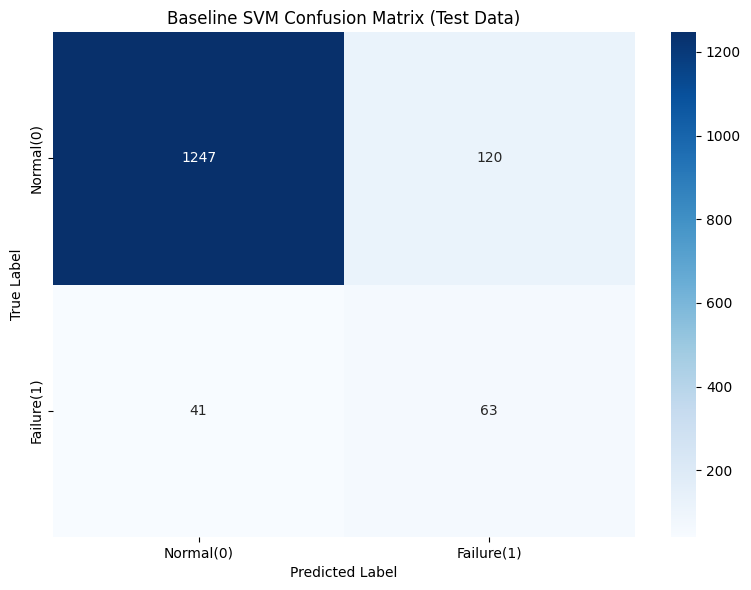

In [ ]:
print("\n" + "="*50)
target_rank = 1  # 분석하고 싶은 순위를 입력하세요 (기본값: 1위)
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

# 1. top_models에서 원하는 순위의 파라미터 추출
selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('svm__', '')}: {value}")

# 2. 추출한 파라미터로 모델 재학습
selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(
        C=selected_params.get('svm__C', 1.0),
        kernel=selected_params.get('svm__kernel', 'rbf'),
        gamma=selected_params.get('svm__gamma', 'scale'),
        probability=True,
        random_state=42
    ))
])
selected_model.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_train_pred_selected = selected_model.predict(X_train_scaled)
y_test_pred_selected = selected_model.predict(X_test_scaled)

# 4. 평가지표 출력 함수
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

# 5. Train / Test 결과 출력
print_metrics(y_train, y_train_pred_selected, "Train")
print_metrics(y_test, y_test_pred_selected, "Test")

# 6. 다음 셀의 시각화를 위해 변수 저장
y_test_pred = y_test_pred_selected

### Cell 7: 최종 모델 Confusion Matrix 시각화

In [ ]:
# SVM의 경우 RBF(비선형) 커널이 선택될 확률이 높기 때문에,
# 로지스틱 회귀와 달리 명시적인 Feature Importance 가중치(coef_)를 시각화하는 부분은 뺐습니다.
# (대신 Confusion Matrix만 집중해서 보여줍니다.)

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])

plt.title(f'SVM (Rank {target_rank}) Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()